In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── PATHS ────────────────────────────────────────────────────
COMBINED_CSV = "/Users/aditibharadwaj/Documents/experiqs/MH_SOC/S2_timeseries_combined.csv"

# ── SEQUENCE CONFIG ──────────────────────────────────────────
SEQ_LEN    = 48
BAND_COLS  = ["B2", "B3", "B4", "B8", "B11", "B12"]
N_FEATURES = len(BAND_COLS)
VALID_SCL  = [4, 5]

# ── SPATIAL CV CONFIG ────────────────────────────────────────
N_SPATIAL_FOLDS = 5      # number of spatial blocks
SPATIAL_RANDOM_STATE = 42

# ── TRAINING CONFIG ──────────────────────────────────────────
BATCH_SIZE    = 64
HIDDEN_SIZE   = 128
NUM_LAYERS    = 2
DROPOUT       = 0.3
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 50
PATIENCE      = 10
VAL_FRACTION  = 0.15    # fraction of train fold used for val/early stopping

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: mps


In [2]:
df = pd.read_csv(COMBINED_CSV, low_memory=False)
df["tile_date"] = pd.to_datetime(df["tile_date"])
df["sample_date_clean"] = pd.to_datetime(df["sample_date_clean"])

# SCL filter
df = df[df["SCL"].isin(VALID_SCL)].copy()

# Drop rows with missing bands
df = df.dropna(subset=BAND_COLS).copy()

# Sort chronologically within each point
df = df.sort_values(["id", "tile_date"]).reset_index(drop=True)

# Drop points with fewer than 5 observations
obs_counts = df.groupby("id").size()
valid_ids  = obs_counts[obs_counts >= 5].index
df = df[df["id"].isin(valid_ids)].copy()

print(f"Total rows:           {len(df):,}")
print(f"Unique points:        {df['id'].nunique():,}")
print(f"Avg obs per point:    {len(df)/df['id'].nunique():.1f}")
print(f"OC range:             {df['OC'].min():.3f} — {df['OC'].max():.3f}")

Total rows:           3,778,662
Unique points:        29,942
Avg obs per point:    126.2
OC range:             0.007 — 3.500


In [3]:
# One row per unique point with its lat, lon, OC
point_meta = (
    df.groupby("id")[["lat_key", "lon_key", "OC"]]
    .first()
    .reset_index()
)
print(f"Point metadata shape: {point_meta.shape}")
point_meta.head(3)

Point metadata shape: (29942, 4)


,id,lat_key,lon_key,OC
0,Maha_OC_00000001,15.709677,74.047631,1.590
1,Maha_OC_00000002,15.709731,74.048897,1.384
2,Maha_OC_00000003,15.711065,74.047657,1.316


Points per spatial block:
  Block 0: 5,551 points
  Block 1: 6,681 points
  Block 2: 7,266 points
  Block 3: 5,640 points
  Block 4: 4,804 points


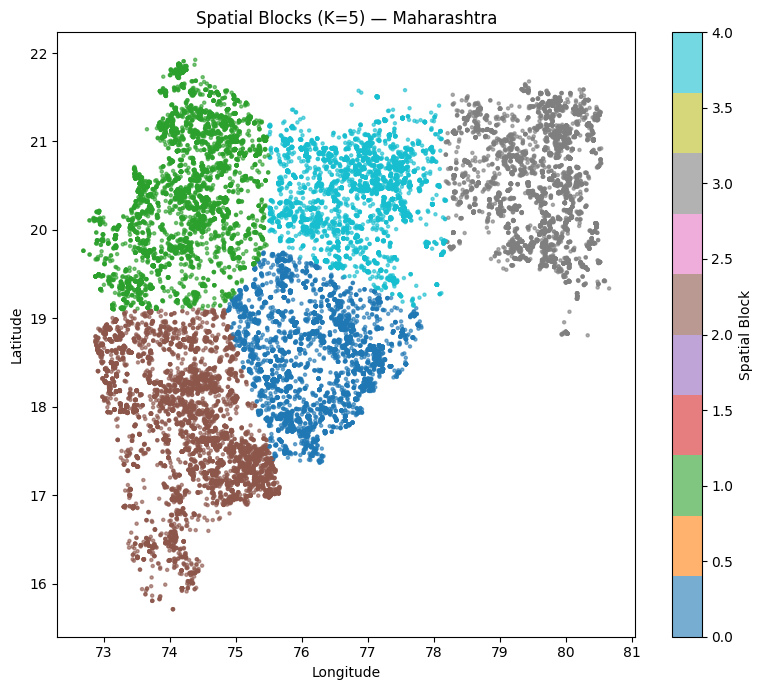

In [4]:
coords = point_meta[["lat_key", "lon_key"]].values

kmeans = KMeans(
    n_clusters=N_SPATIAL_FOLDS,
    random_state=SPATIAL_RANDOM_STATE,
    n_init=10
)
point_meta["spatial_block"] = kmeans.fit_predict(coords)

# Show block sizes
block_counts = point_meta["spatial_block"].value_counts().sort_index()
print("Points per spatial block:")
for block, count in block_counts.items():
    print(f"  Block {block}: {count:,} points")

# Visualise the spatial blocks
fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(
    point_meta["lon_key"], point_meta["lat_key"],
    c=point_meta["spatial_block"], cmap="tab10",
    s=5, alpha=0.6
)
plt.colorbar(scatter, ax=ax, label="Spatial Block")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Spatial Blocks (K={N_SPATIAL_FOLDS}) — Maharashtra")
plt.tight_layout()
plt.savefig("spatial_blocks.png", dpi=150)
plt.show()

In [5]:
def build_sequences(df_subset, seq_len, band_cols, scaler=None, fit_scaler=False):
    """
    Build fixed-length padded sequences from a subset of the long-format dataframe.
    If fit_scaler=True, fits scaler on this subset (use for train only).
    If scaler is provided, transforms using it (use for val/test).
    Returns X (n, seq_len, features), y (n,), ids, fitted_scaler
    """
    if fit_scaler:
        scaler = StandardScaler()
        df_subset = df_subset.copy()
        df_subset[band_cols] = scaler.fit_transform(df_subset[band_cols])
    elif scaler is not None:
        df_subset = df_subset.copy()
        df_subset[band_cols] = scaler.transform(df_subset[band_cols])

    X_list, y_list, id_list = [], [], []
    for pt_id, group in df_subset.groupby("id", sort=False):
        bands = group[band_cols].values.astype(np.float32)
        oc    = float(group["OC"].iloc[0])
        T = len(bands)
        if T >= seq_len:
            seq = bands[-seq_len:]
        else:
            pad = np.zeros((seq_len - T, len(band_cols)), dtype=np.float32)
            seq = np.vstack([pad, bands])
        X_list.append(seq)
        y_list.append(oc)
        id_list.append(pt_id)

    return (
        np.stack(X_list),
        np.array(y_list, dtype=np.float32),
        id_list,
        scaler
    )


class SOCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


class SOC_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, preds, targets = 0, [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out = model(X_b)
            total_loss += criterion(out, y_b).item() * len(X_b)
            preds.extend(out.cpu().numpy().flatten())
            targets.extend(y_b.cpu().numpy().flatten())
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(preds), np.array(targets)


def train_one_fold(X_tr, y_tr, X_val, y_val, X_te, y_te, fold, parent_run_id):
    """Train LSTM on one spatial fold, log as nested MLflow run."""

    with mlflow.start_run(
        run_name=f"fold_{fold}",
        nested=True,
        tags={"fold": str(fold), "parent_run_id": parent_run_id}
    ):
        mlflow.log_params({
            "fold":         fold,
            "n_train":      len(X_tr),
            "n_val":        len(X_val),
            "n_test":       len(X_te),
            "hidden_size":  HIDDEN_SIZE,
            "num_layers":   NUM_LAYERS,
            "dropout":      DROPOUT,
            "learning_rate":LEARNING_RATE,
            "seq_len":      SEQ_LEN,
            "batch_size":   BATCH_SIZE,
        })

        train_loader = DataLoader(SOCDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(SOCDataset(X_val, y_val), batch_size=BATCH_SIZE)
        test_loader  = DataLoader(SOCDataset(X_te, y_te),  batch_size=BATCH_SIZE)

        model     = SOC_LSTM(N_FEATURES, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=5, factor=0.5
        )

        best_val_loss    = float("inf")
        patience_counter = 0
        best_weights     = None

        for epoch in range(1, NUM_EPOCHS + 1):
            # Train
            model.train()
            epoch_loss = 0
            for X_b, y_b in train_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(X_b), y_b)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += loss.item() * len(X_b)
            train_loss = epoch_loss / len(train_loader.dataset)

            # Validate
            val_loss, val_preds, val_tgts = evaluate(model, val_loader, criterion, DEVICE)
            val_r2   = r2_score(val_tgts, val_preds)
            val_rmse = np.sqrt(mean_squared_error(val_tgts, val_preds))

            scheduler.step(val_loss)
            current_lr = optimizer.param_groups[0]['lr']

            mlflow.log_metrics({
                "train_loss":   train_loss,
                "val_loss":     val_loss,
                "val_r2":       val_r2,
                "val_rmse":     val_rmse,
                "learning_rate":current_lr,
            }, step=epoch)

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print(f"    Fold {fold} — early stop at epoch {epoch}")
                    break

        # Test evaluation with best weights
        model.load_state_dict(best_weights)
        test_loss, test_preds, test_tgts = evaluate(model, test_loader, criterion, DEVICE)
        test_r2   = r2_score(test_tgts, test_preds)
        test_mae  = mean_absolute_error(test_tgts, test_preds)
        test_rmse = np.sqrt(mean_squared_error(test_tgts, test_preds))

        mlflow.log_metrics({
            "test_r2":   test_r2,
            "test_mae":  test_mae,
            "test_rmse": test_rmse,
            "test_loss": test_loss,
        })
        mlflow.pytorch.log_model(model, f"lstm_fold_{fold}")

        print(f"  Fold {fold} | R²: {test_r2:.4f} | "
              f"RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f}")

        return {
            "fold":       fold,
            "test_r2":    test_r2,
            "test_rmse":  test_rmse,
            "test_mae":   test_mae,
            "preds":      test_preds,
            "targets":    test_tgts,
        }

print("Helpers defined")

Helpers defined


## Spatial CV Training Loop

In [6]:
mlflow.set_experiment("SOC_RF_Tabular")
fold_results = []

with mlflow.start_run(run_name="LSTM_SpatialCV") as parent_run:

    # Log top-level config
    mlflow.log_params({
        "model":            "LSTM_SpatialCV",
        "n_spatial_folds":  N_SPATIAL_FOLDS,
        "seq_len":          SEQ_LEN,
        "n_features":       N_FEATURES,
        "valid_scl":        str(VALID_SCL),
        "hidden_size":      HIDDEN_SIZE,
        "num_layers":       NUM_LAYERS,
        "dropout":          DROPOUT,
        "learning_rate":    LEARNING_RATE,
        "batch_size":       BATCH_SIZE,
        "num_epochs":       NUM_EPOCHS,
        "patience":         PATIENCE,
        "total_points":     df['id'].nunique(),
    })
    mlflow.log_artifact("spatial_blocks.png")

    for fold in range(N_SPATIAL_FOLDS):
        print(f"\n── Fold {fold+1}/{N_SPATIAL_FOLDS} ────────────────────────")

        # ── Split point IDs by spatial block ─────────────────
        test_ids  = point_meta[point_meta["spatial_block"] == fold]["id"].values
        train_ids = point_meta[point_meta["spatial_block"] != fold]["id"].values

        # ── Further split train into train/val ───────────────
        n_val = max(1, int(len(train_ids) * VAL_FRACTION))
        rng = np.random.default_rng(42 + fold)
        rng.shuffle(train_ids)
        val_ids   = train_ids[:n_val]
        train_ids = train_ids[n_val:]

        print(f"  Train: {len(train_ids):,} | Val: {len(val_ids):,} | Test: {len(test_ids):,}")

        # ── Subset long-format df ────────────────────────────
        df_train = df[df["id"].isin(train_ids)]
        df_val   = df[df["id"].isin(val_ids)]
        df_test  = df[df["id"].isin(test_ids)]

        # ── Build sequences (fit scaler on train only) ───────
        X_tr, y_tr, _, scaler = build_sequences(
            df_train, SEQ_LEN, BAND_COLS, fit_scaler=True
        )
        X_val, y_val, _, _ = build_sequences(
            df_val, SEQ_LEN, BAND_COLS, scaler=scaler
        )
        X_te, y_te, _, _ = build_sequences(
            df_test, SEQ_LEN, BAND_COLS, scaler=scaler
        )

        # ── Train fold ───────────────────────────────────────
        result = train_one_fold(
            X_tr, y_tr, X_val, y_val, X_te, y_te,
            fold=fold,
            parent_run_id=parent_run.info.run_id
        )
        fold_results.append(result)

    # ── Aggregate metrics across folds ───────────────────────
    r2_scores   = [r["test_r2"]   for r in fold_results]
    rmse_scores = [r["test_rmse"] for r in fold_results]
    mae_scores  = [r["test_mae"]  for r in fold_results]

    mlflow.log_metrics({
        "cv_r2_mean":   np.mean(r2_scores),
        "cv_r2_std":    np.std(r2_scores),
        "cv_rmse_mean": np.mean(rmse_scores),
        "cv_rmse_std":  np.std(rmse_scores),
        "cv_mae_mean":  np.mean(mae_scores),
        "cv_mae_std":   np.std(mae_scores),
    })

    print(f"\n── Spatial CV Summary ────────────────────────────")
    print(f"R²   : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"RMSE : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"MAE  : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")


── Fold 1/5 ────────────────────────
  Train: 20,733 | Val: 3,658 | Test: 5,551
    Fold 0 — early stop at epoch 50


2026/06/22 10:01:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 10:01:31 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


  Fold 0 | R²: -0.0763 | RMSE: 0.2621 | MAE: 0.1765

── Fold 2/5 ────────────────────────
  Train: 19,772 | Val: 3,489 | Test: 6,681


2026/06/22 10:03:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 10:03:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


  Fold 1 | R²: -0.1338 | RMSE: 0.4659 | MAE: 0.2713

── Fold 3/5 ────────────────────────
  Train: 19,275 | Val: 3,401 | Test: 7,266


...

  Fold 2 | R²: -0.0430 | RMSE: 0.6225 | MAE: 0.3968

── Fold 4/5 ────────────────────────
  Train: 20,657 | Val: 3,645 | Test: 5,640


2026/06/22 10:08:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 10:08:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


  Fold 3 | R²: -3.3714 | RMSE: 0.6052 | MAE: 0.4373

── Fold 5/5 ────────────────────────
  Train: 21,368 | Val: 3,770 | Test: 4,804


2026/06/22 10:11:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/22 10:11:35 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


  Fold 4 | R²: -0.1729 | RMSE: 0.2511 | MAE: 0.1828

── Spatial CV Summary ────────────────────────────
R²   : -0.7595 ± 1.3067
RMSE : 0.4414 ± 0.1604
MAE  : 0.2929 ± 0.1075


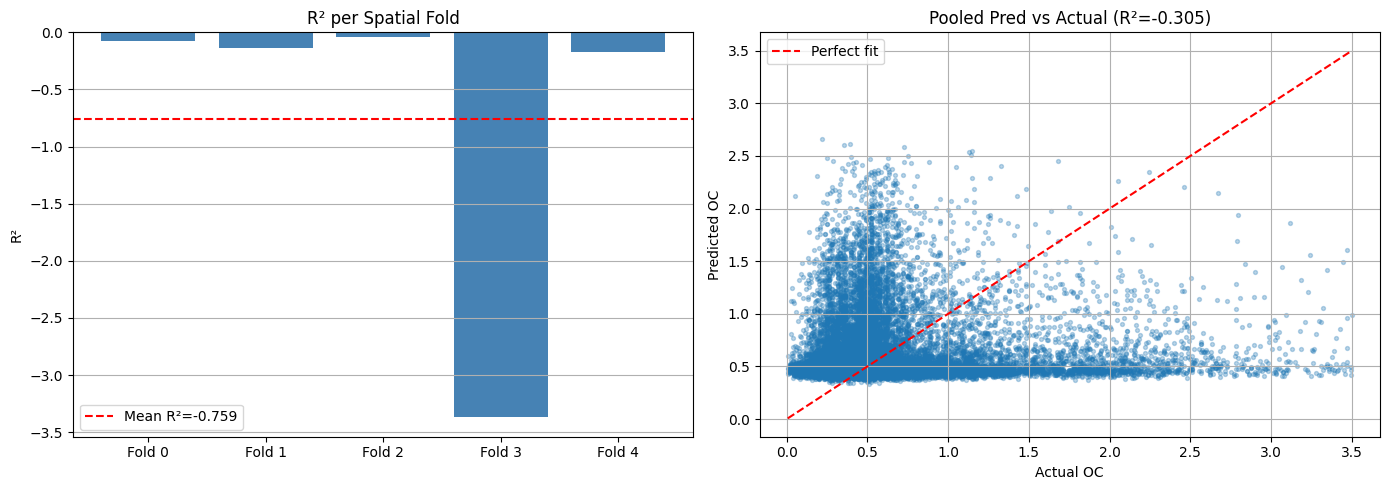

Saved: spatial_cv_diagnostics.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-fold metrics bar chart
folds = [f"Fold {r['fold']}" for r in fold_results]
axes[0].bar(folds, [r["test_r2"]   for r in fold_results], color="steelblue")
axes[0].axhline(np.mean(r2_scores), color="red", linestyle="--", label=f"Mean R²={np.mean(r2_scores):.3f}")
axes[0].set_ylabel("R²")
axes[0].set_title("R² per Spatial Fold")
axes[0].legend()
axes[0].grid(axis="y")

# Pooled predicted vs actual across all folds
all_preds   = np.concatenate([r["preds"]   for r in fold_results])
all_targets = np.concatenate([r["targets"] for r in fold_results])
overall_r2  = r2_score(all_targets, all_preds)

axes[1].scatter(all_targets, all_preds, alpha=0.3, s=8)
mn, mx = all_targets.min(), all_targets.max()
axes[1].plot([mn, mx], [mn, mx], "r--", label="Perfect fit")
axes[1].set_xlabel("Actual OC")
axes[1].set_ylabel("Predicted OC")
axes[1].set_title(f"Pooled Pred vs Actual (R²={overall_r2:.3f})")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("spatial_cv_diagnostics.png", dpi=150)
plt.show()
print("Saved: spatial_cv_diagnostics.png")